# K-Nearest Neighbors (KNN) from Scratch 📍

In this notebook, we implement **K-Nearest Neighbors (KNN)**, a simple yet powerful instance-based learning algorithm.

## 📖 Theoretical Background

KNN is a **non-parametric** and **lazy learning** algorithm. It doesn't learn a discriminative function from the training data but instead memorizes the entire training dataset.

### 1. The Algorithm
For a given test point $x$:
1. Calculate the distance between $x$ and all points in the training set.
2. Select the $K$ points with the smallest distances.
3. Perform a majority vote (classification) or average (regression) among these $K$ points.

### 2. Distance Metrics
The choice of distance metric is crucial. Two common ones are:
- **Euclidean Distance**:
  $$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$
- **Manhattan Distance**:
  $$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

np.random.seed(42)

## 🏗️ The Implementation

In [2]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))

class KNN:
    def __init__(self, k=3, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
        if distance_metric == 'euclidean':
            self.dist_fn = euclidean_distance
        else:
            self.dist_fn = manhattan_distance

    def fit(self, X, y):
        # KNN just stores the training data
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):
        # 1. Compute distances
        distances = [self.dist_fn(x, x_train) for x_train in self.X_train]
        
        # 2. Get k nearest samples, labels
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
        # 3. Majority vote
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

## 🧪 Data Generation and Training

In [3]:
# Generate data with 3 clusters
X, y = make_blobs(n_samples=300, centers=3, n_features=2, cluster_std=1.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Instantiate and fit model
clf = KNN(k=5)
clf.fit(X_train, y_train)

predictions = clf.predict(X_test)
accuracy = np.sum(predictions == y_test) / len(y_test)
print(f"KNN Classification Accuracy: {accuracy * 100:.2f}%")

KNN Classification Accuracy: 100.00%


## 📊 Visualization

We will visualize the decision regions by predicting on a grid.

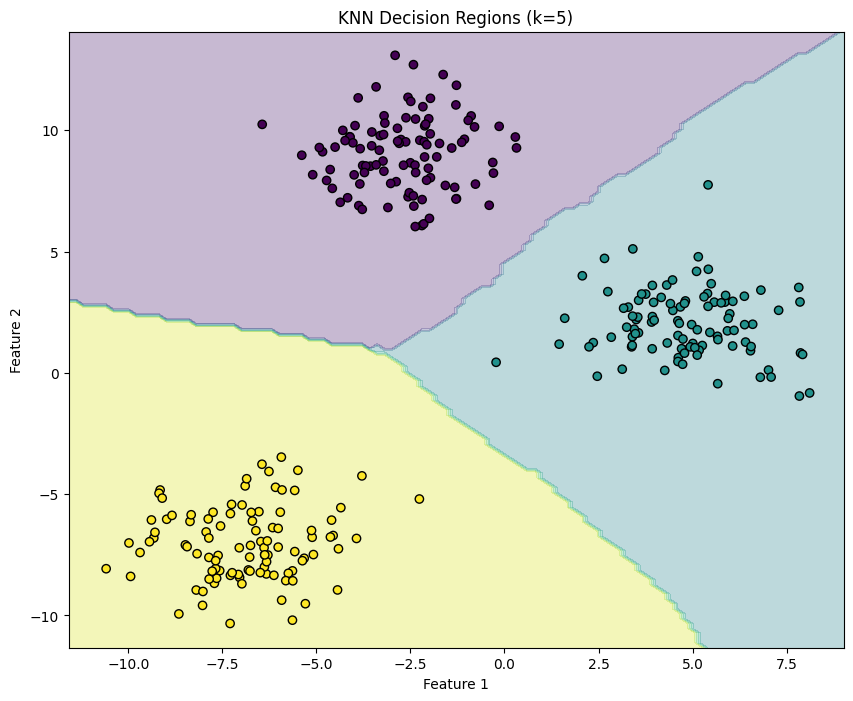

In [4]:
plt.figure(figsize=(10, 8))

# Create mesh grid
h = 0.2 # step size
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot contour
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title(f"KNN Decision Regions (k={clf.k})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 📊 Additional Visualizations

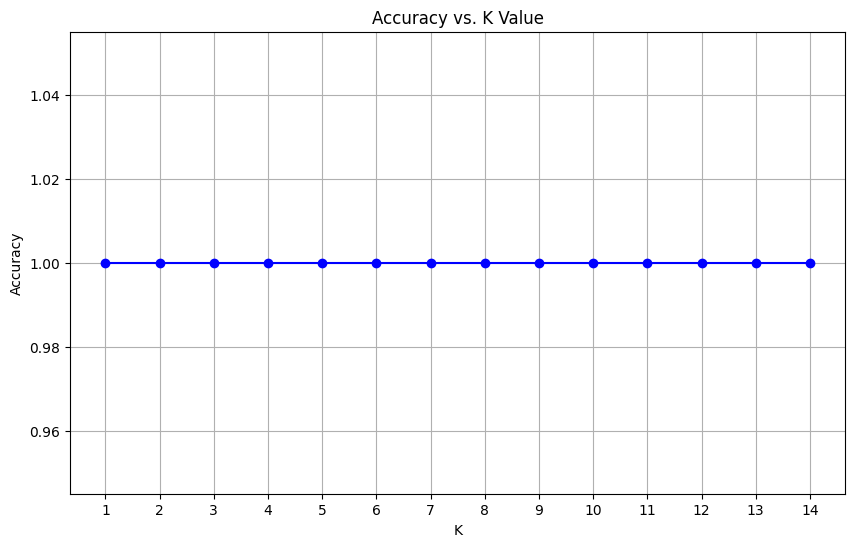

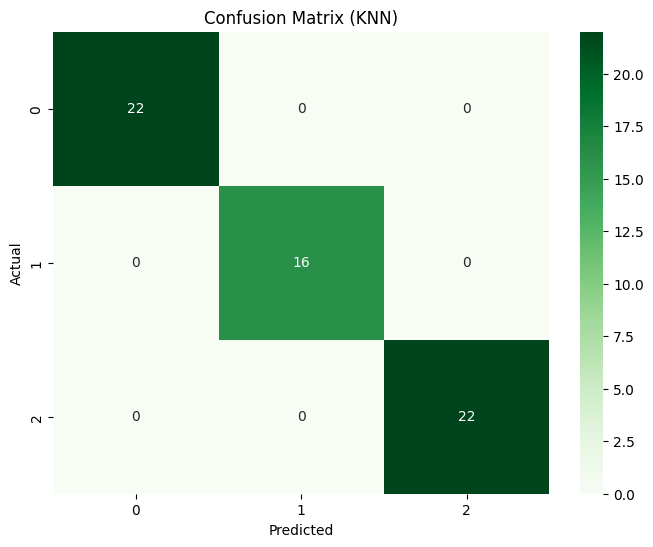

In [5]:

# 1. Elbow Method for Optimal K
k_values = range(1, 15)
accuracies = []

for k in k_values:
    temp_knn = KNN(k=k)
    temp_knn.fit(X_train, y_train)
    temp_preds = temp_knn.predict(X_test)
    acc = np.sum(temp_preds == y_test) / len(y_test)
    accuracies.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.title('Accuracy vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# 2. Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (KNN)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


---

## ⚖️ Weighted K-Nearest Neighbors

In standard KNN, all $K$ neighbors have an equal vote. In **Weighted KNN**, we assign a weight to each neighbor, typically inversely proportional to its distance from the test point. This ensures that closer neighbors have a greater influence on the final prediction.

The weight $w_j$ for neighbor $j$ is often calculated as:
$$w_j = \frac{1}{d(x, x_j) + \epsilon}$$
where $\epsilon$ is a small constant to avoid division by zero.

In [6]:
class WeightedKNN(KNN):
    def __init__(self, k=3, distance_metric='euclidean', epsilon=1e-8):
        super().__init__(k, distance_metric)
        self.epsilon = epsilon
        
    def _predict(self, x):
        # 1. Compute distances
        distances = np.array([self.dist_fn(x, x_train) for x_train in self.X_train])
        
        # 2. Get k nearest samples, labels, and distances
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = self.y_train[k_indices]
        k_distances = distances[k_indices]
        
        # 3. Calculate weights (inverse distance)
        weights = 1.0 / (k_distances + self.epsilon)
        
        # 4. Weighted vote
        class_weights = {}
        for i, label in enumerate(k_nearest_labels):
            class_weights[label] = class_weights.get(label, 0) + weights[i]
            
        return max(class_weights, key=class_weights.get)

# Instantiate and fit model
w_clf = WeightedKNN(k=5)
w_clf.fit(X_train, y_train)

w_predictions = w_clf.predict(X_test)
w_accuracy = np.sum(w_predictions == y_test) / len(y_test)
print(f"Weighted KNN Classification Accuracy: {w_accuracy * 100:.2f}%")

Weighted KNN Classification Accuracy: 100.00%


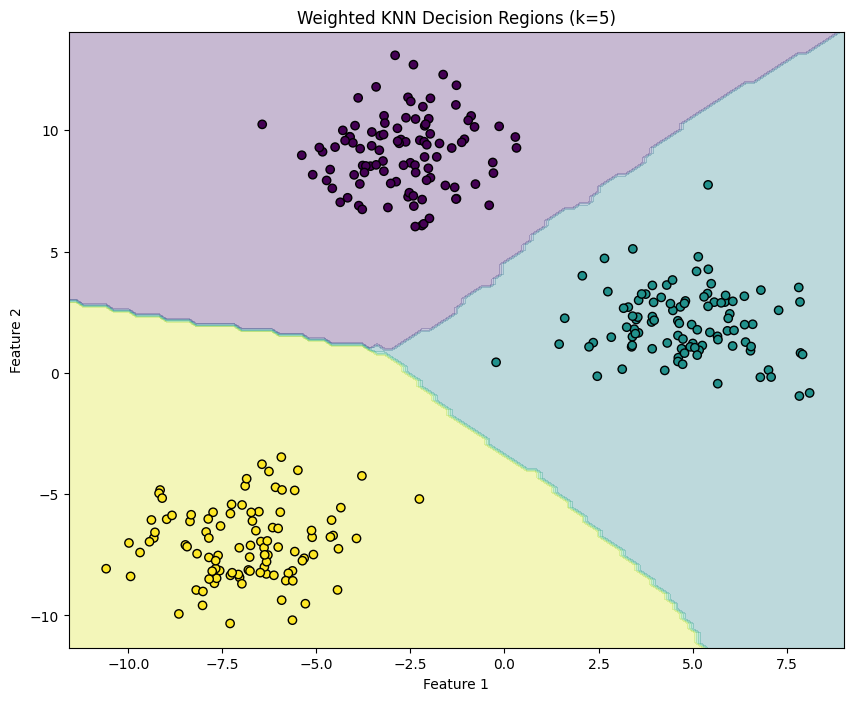

In [7]:
plt.figure(figsize=(10, 8))

# Predict on grid using Weighted KNN
Z_weighted = w_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z_weighted = Z_weighted.reshape(xx.shape)

# Plot contour
plt.contourf(xx, yy, Z_weighted, alpha=0.3, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title(f"Weighted KNN Decision Regions (k={w_clf.k})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

---

## 🌫️ Fuzzy K-Nearest Neighbors

**Fuzzy KNN** (Keller et al., 1985) assigns a degree of membership to each class for a given test point, rather than a single hard label. This is particularly useful for points near decision boundaries.

The membership $u_i(x)$ of point $x$ in class $i$ is:
$$u_i(x) = \frac{\sum_{j=1}^K w_j u_{ij}}{\sum_{j=1}^K w_j}$$
where $u_{ij}$ is the membership of the $j$-th neighbor in class $i$ (usually 1 if it belongs to class $i$, 0 otherwise), and the weight $w_j$ is:
$$w_j = \frac{1}{\|x - x_j\|^{2/(m-1)}}$$
where $m$ is the fuzziness parameter (typically $m=2$).

In [8]:
class FuzzyKNN(KNN):
    def __init__(self, k=3, distance_metric='euclidean', m=2, epsilon=1e-8):
        super().__init__(k, distance_metric)
        self.m = m
        self.epsilon = epsilon
        
    def fit(self, X, y):
        super().fit(X, y)
        self.classes = np.unique(y)
        
    def predict_proba(self, X):
        return np.array([self._predict_proba(x) for x in X])
        
    def predict(self, X):
        probas = self.predict_proba(X)
        return self.classes[np.argmax(probas, axis=1)]
        
    def _predict_proba(self, x):
        # 1. Compute distances
        distances = np.array([self.dist_fn(x, x_train) for x_train in self.X_train])
        
        # 2. Get k nearest samples, labels, and distances
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = self.y_train[k_indices]
        k_distances = distances[k_indices]
        
        # 3. Calculate weights based on fuzziness m
        # w = 1 / (d^(2/(m-1)))
        weights = 1.0 / (k_distances**(2 / (self.m - 1)) + self.epsilon)
        
        # 4. Calculate membership for each class
        probas = np.zeros(len(self.classes))
        for i, c in enumerate(self.classes):
            u_ij = (k_nearest_labels == c).astype(float)
            probas[i] = np.sum(weights * u_ij) / np.sum(weights)
            
        return probas

# Instantiate and fit model
f_clf = FuzzyKNN(k=5, m=2)
f_clf.fit(X_train, y_train)

f_predictions = f_clf.predict(X_test)
f_accuracy = np.sum(f_predictions == y_test) / len(y_test)
print(f"Fuzzy KNN Classification Accuracy: {f_accuracy * 100:.2f}%")

Fuzzy KNN Classification Accuracy: 100.00%


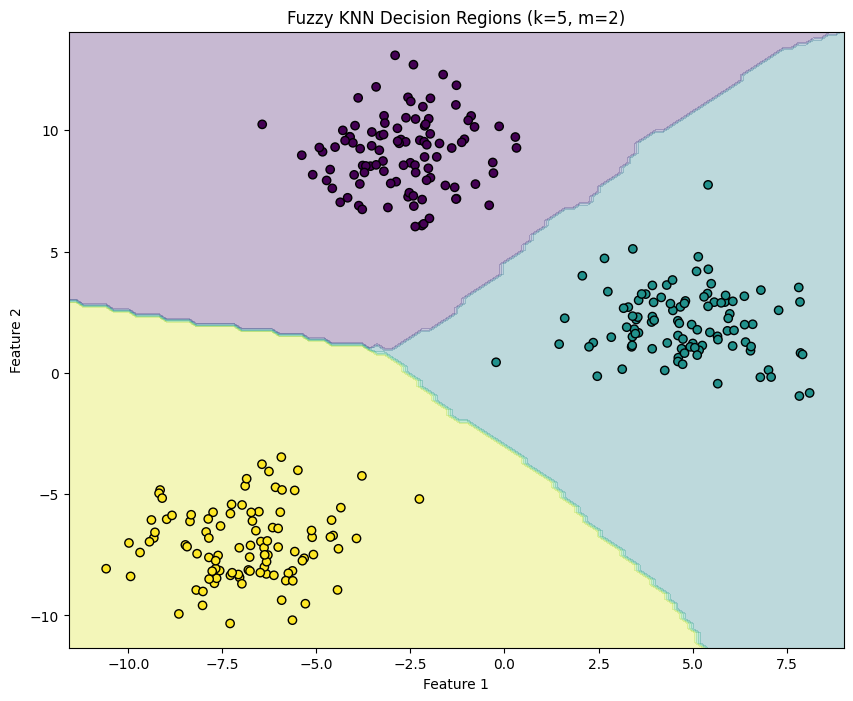

In [9]:
plt.figure(figsize=(10, 8))

# Predict on grid using Fuzzy KNN labels
Z_fuzzy = f_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z_fuzzy = Z_fuzzy.reshape(xx.shape)

# Plot contour
plt.contourf(xx, yy, Z_fuzzy, alpha=0.3, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title(f"Fuzzy KNN Decision Regions (k={f_clf.k}, m={f_clf.m})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

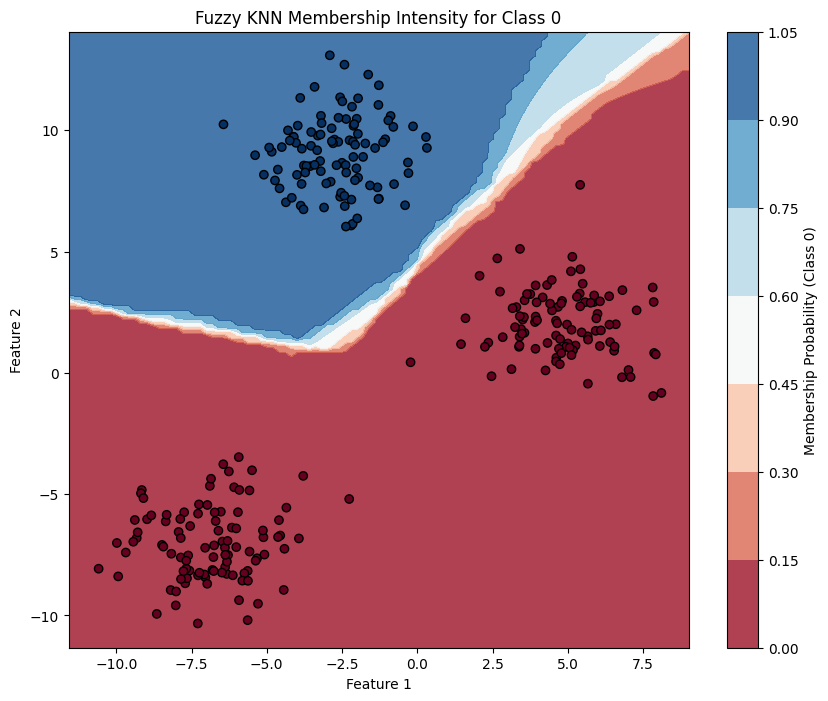

In [10]:
# Visualize membership probability for Class 0
Z_proba = f_clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 0]
Z_proba = Z_proba.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_proba, alpha=0.8, cmap='RdBu')
plt.colorbar(label='Membership Probability (Class 0)')
plt.scatter(X[:, 0], X[:, 1], c=(y==0), cmap='RdBu', edgecolors='k')
plt.title(f"Fuzzy KNN Membership Intensity for Class 0")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()